# Linear Regression in raw Python

In [1]:
# Import Libraries
import numpy as np 
import matplotlib.pyplot as plt

## Linear Regression Algorithm Implementation

In [2]:
class LinearRegression:
    def __init__(self):
        self.m = None # Slope
        self.b = None # Intercept
    
    def fit(self, X, y):
        """
        Train the model to find the value of m and b
        X = Input features
        y = Target values
        """

        x_mean = np.mean(X)
        y_mean = np.mean(y)

        # Calculate Slope
        numerator = np.sum((X - x_mean) * (y - y_mean))
        denominator = np.sum((X - x_mean) ** 2)
        self.m = numerator / denominator

        # Calculate Intercept
        self.b = y_mean - (self.m * x_mean)

        print(f"Slope (m) = {self.m}")
        print(f"Intercept (b) = {self.b}", end='\n\n')

    def predict(self, X):
        """
        Make predictions using y = mx + b
        """
        if self.m is None or self.b is None:
            raise Exception("Model not trained! Call fit() first")
        
        return self.m * X + self.b
    
    def score(self, X, y):
        """
        Performance Matrices:

        Calculate R^2 score to know how well our line fits
        R^2 = 1 means perfect fit
        R^2 = 0 means no better than average
        """

        y_pred = self.predict(X)

        # Total Sum of Squares
        ss_total = np.sum((y - np.mean(y)) ** 2)

        # Residual Sum of Squares
        ss_residual = np.sum((y - y_pred) ** 2)

        r2 = 1 - (ss_residual / ss_total)
        return r2

## Apply Linear Regression in raw House Prices Data

Slope (m) = 0.2
Intercept (b) = 0.0

Model Predited Prices:
House Size: 1200 sq.fit, Predicted Price: $240.0,000
House Size: 1800 sq.fit, Predicted Price: $360.0,000
House Size: 2200 sq.fit, Predicted Price: $440.0,000

Model R^2 Score: 100.0%


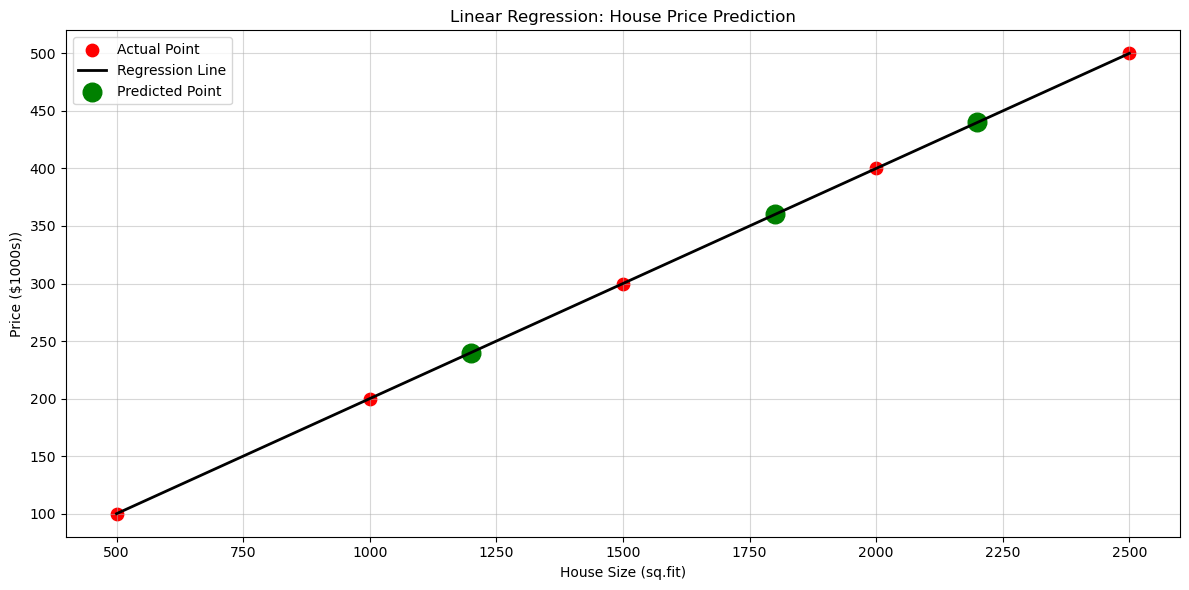

In [3]:
if __name__ == "__main__":
    # House Prices Dataset
    house_sizes = np.array([500, 1000, 1500, 2000, 2500]) 
    house_prices = np.array([100, 200, 300, 400, 500])

    # Create Linear Regression Model
    model = LinearRegression()

    # Train the Model with house sizes and prices data
    model.fit(house_sizes, house_prices)

    # Make Predictions
    test_sizes = np.array([1200, 1800, 2200])
    prediction = model.predict(test_sizes)

    print("Model Predited Prices:")
    for size, price in zip(test_sizes, prediction):
        print(f"House Size: {size} sq.fit, Predicted Price: ${price},000")

    print()
    # Calculate Accuracy
    r2_score = model.score(house_sizes, house_prices)
    print(f"Model R^2 Score: {r2_score * 100:.1f}%")

    # Visualize
    plt.figure(figsize=(12, 6))
    plt.scatter(house_sizes, house_prices, s=80, color='red', label='Actual Point')
    plt.plot(house_sizes, model.predict(house_sizes), color='black', lw=2, label='Regression Line')
    plt.scatter(test_sizes, prediction, color='green', s=180, label='Predicted Point')
    plt.xlabel("House Size (sq.fit)")
    plt.ylabel("Price ($1000s))")
    plt.title("Linear Regression: House Price Prediction")
    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.show()